In [26]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

os.chdir(r"C:\Users\Asus\grocery-cv-project")

DATA_DIR = Path("data/raw/freiburg_groceries")

print("Working directory:", os.getcwd())
print("Dataset exists:", DATA_DIR.exists())
print("Train split exists:", (DATA_DIR / "splits" / "train0.txt").exists())
print("Images folder exists:", (DATA_DIR / "images").exists())

Working directory: C:\Users\Asus\grocery-cv-project
Dataset exists: True
Train split exists: True
Images folder exists: True


In [27]:
def load_split(split_file):
    rows = []
    with open(split_file, "r") as f:
        for line in f:
            img_rel, label = line.strip().split()
            rows.append({
                "image_path": str(DATA_DIR / "images" / img_rel),
                "label_id": int(label),
                "class_name": img_rel.split("/")[0]
            })
    return pd.DataFrame(rows)

train_df = load_split(DATA_DIR / "splits" / "train0.txt")
test_df = load_split(DATA_DIR / "splits" / "test0.txt")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Number of classes:", train_df["class_name"].nunique())

train_df.head()

Train shape: (7425, 3)
Test shape: (1018, 3)
Number of classes: 25


,image_path,label_id,class_name
0,data\raw\freiburg_groceries\images\TEA\TEA0123...,16,TEA
1,data\raw\freiburg_groceries\images\CHOCOLATE\C...,4,CHOCOLATE
2,data\raw\freiburg_groceries\images\COFFEE\COFF...,14,COFFEE
3,data\raw\freiburg_groceries\images\CHOCOLATE\C...,4,CHOCOLATE
4,data\raw\freiburg_groceries\images\SUGAR\SUGAR...,20,SUGAR


In [28]:
train_df["class_name"].value_counts()

class_name
TEA             297
CHOCOLATE       297
COFFEE          297
SUGAR           297
RICE            297
BEANS           297
SPICES          297
FLOUR           297
JUICE           297
FISH            297
CAKE            297
CORN            297
MILK            297
NUTS            297
OIL             297
CHIPS           297
HONEY           297
WATER           297
VINEGAR         297
PASTA           297
CANDY           297
TOMATO_SAUCE    297
SODA            297
JAM             297
CEREAL          297
Name: count, dtype: int64

In [29]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 4947 files belonging to 25 classes.
Using 3958 files for training.
Found 4947 files belonging to 25 classes.
Using 989 files for validation.
Classes: ['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']
Number of classes: 25


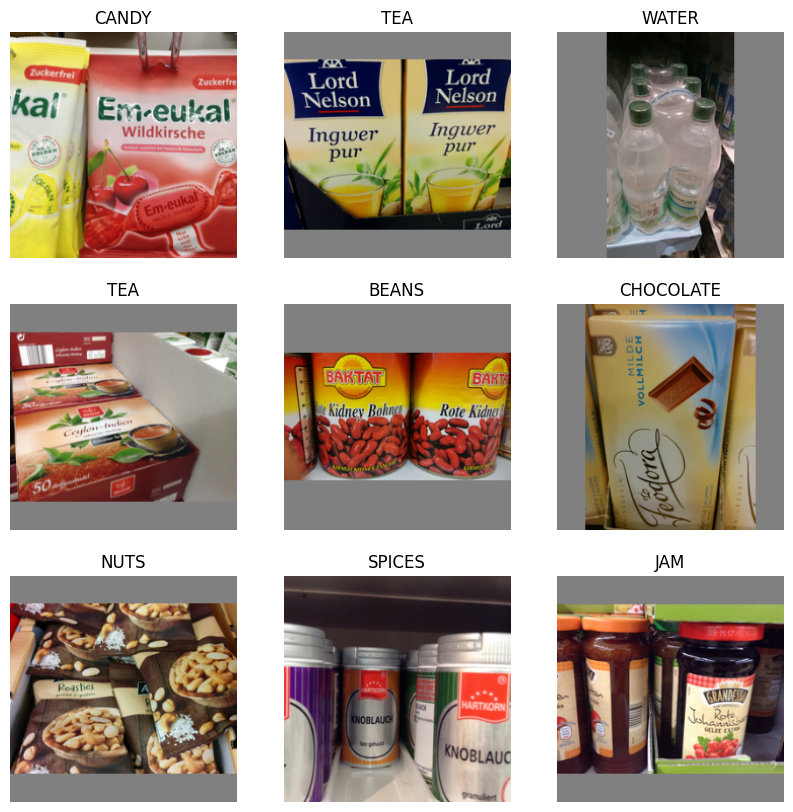

In [30]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

mobilenet_model = tf.keras.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,290,009 (8.74 MB)

 Trainable params: 32,025 (125.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 51s 372ms/step - accuracy: 0.2916 - loss: 2.4919 - val_accuracy: 0.4793 - val_loss: 1.7447
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - accuracy: 0.5253 - loss: 1.5759 - val_accuracy: 0.5713 - val_loss: 1.4013
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.6036 - loss: 1.3384 - val_accuracy: 0.6198 - val_loss: 1.2575
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 46s 369ms/step - accuracy: 0.6501 - loss: 1.1740 - val_accuracy: 0.6491 - val_loss: 1.1603
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 48s 388ms/step - accuracy: 0.6814 - loss: 1.0695 - val_accuracy: 0.6471 - val_loss: 1.1431
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 46s 373ms/step - accuracy: 0.6895 - loss: 1.0036 - val_accuracy: 0.6764 - val_loss: 1.0601
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 44s 351ms/step - accuracy: 0.7148 - loss: 0.9503 - val_accuracy: 0.6623 - val_loss: 1.0676
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 46s 373ms/step - accuracy: 0.7350 - loss: 0

In [34]:
loss, acc = mobilenet_model.evaluate(val_ds)
print("MobileNet validation accuracy:", acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.6967 - loss: 0.9448
MobileNet validation accuracy: 0.6966633200645447


In [35]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_fine_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9217 - loss: 0.2445 - val_accuracy: 0.8311 - val_loss: 0.5772
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9325 - loss: 0.2156 - val_accuracy: 0.8392 - val_loss: 0.5642
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1119s 9s/step - accuracy: 0.9444 - loss: 0.1836 - val_accuracy: 0.8392 - val_loss: 0.5553
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9477 - loss: 0.1757 - val_accuracy: 0.8504 - val_loss: 0.5415
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 8013s 65s/step - accuracy: 0.9548 - loss: 0.1472 - val_accuracy: 0.8483 - val_loss: 0.5300
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 31804s 259s/step - accuracy: 0.9578 - loss: 0.1394 - val_accuracy: 0.8493 - val_loss: 0.5237
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9624 - loss: 0.1337 - val_accuracy: 0.8463 - val_loss: 0.5239
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9694 - loss: 0.1150 - v

In [53]:
FREIBURG_MODEL_PATH = Path("models/freiburg_resnet50_model.keras")

In [39]:
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

In [40]:
resnet_model.save("../models/resnet50_grocery.keras")

In [43]:
from pathlib import Path

EGYPT_DIR = Path(
    "data/raw/egyptain_food/Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip"
)

train_dir = EGYPT_DIR / "train"

classes = [x.name for x in train_dir.iterdir() if x.is_dir()]

print("Number of classes:", len(classes))

for c in classes:
    print(c)

Number of classes: 8
Bisco Misr Luxe Original Plain Biscuits Extra size
Bisco Misr Max Tea Biscuits
Bisco Misr Wafer Vanilla Big
Heinz Tomato Ketchup Grill
Oniro Teabix Biscuits
Shepsy Salt and Vinegar Chips
Shepsy Tomato Chips
Signal Cavity Fighter


In [44]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names

print(class_names)
print("Classes:", len(class_names))

Found 353 files belonging to 8 classes.
Using 283 files for training.
Found 353 files belonging to 8 classes.
Using 70 files for validation.
['Bisco Misr Luxe Original Plain Biscuits Extra size', 'Bisco Misr Max Tea Biscuits', 'Bisco Misr Wafer Vanilla Big', 'Heinz Tomato Ketchup Grill', 'Oniro Teabix Biscuits', 'Shepsy Salt and Vinegar Chips', 'Shepsy Tomato Chips', 'Signal Cavity Fighter']
Classes: 8


In [46]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print(num_classes)

Found 353 files belonging to 8 classes.
Using 283 files for training.
Found 353 files belonging to 8 classes.
Using 70 files for validation.
['Bisco Misr Luxe Original Plain Biscuits Extra size', 'Bisco Misr Max Tea Biscuits', 'Bisco Misr Wafer Vanilla Big', 'Heinz Tomato Ketchup Grill', 'Oniro Teabix Biscuits', 'Shepsy Salt and Vinegar Chips', 'Shepsy Tomato Chips', 'Signal Cavity Fighter']
8


In [47]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

egypt_model = models.Model(inputs, outputs)

egypt_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
history = egypt_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1307 - loss: 2.7273 - val_accuracy: 0.0714 - val_loss: 2.6046
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 935ms/step - accuracy: 0.1413 - loss: 2.5803 - val_accuracy: 0.0714 - val_loss: 2.3865
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1343 - loss: 2.4774 - val_accuracy: 0.0714 - val_loss: 2.2639
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1590 - loss: 2.3189 - val_accuracy: 0.1000 - val_loss: 2.1652
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1979 - loss: 2.2489 - val_accuracy: 0.1429 - val_loss: 2.0657
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1979 - loss: 2.1281 - val_accuracy: 0.1714 - val_loss: 1.9778
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 952ms/step - accuracy: 0.2191 - loss: 2.0723 - val_accuracy: 0.1857 - val_loss: 1.8933
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 919ms/step - accuracy: 0.2509 - loss: 1.9995 - val_accuracy: 0.2143 - val_loss: 1.8240
Epo

In [49]:
# unfreeze only the last part of ResNet
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

egypt_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = egypt_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3534 - loss: 1.7322 - val_accuracy: 0.4286 - val_loss: 1.5484
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4558 - loss: 1.4872 - val_accuracy: 0.5429 - val_loss: 1.3952
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5300 - loss: 1.3497 - val_accuracy: 0.6000 - val_loss: 1.2415
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6360 - loss: 1.1889 - val_accuracy: 0.6143 - val_loss: 1.1105
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6855 - loss: 1.0167 - val_accuracy: 0.6714 - val_loss: 0.9866
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7385 - loss: 0.8600 - val_accuracy: 0.6857 - val_loss: 0.8740
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7350 - loss: 0.8457 - val_accuracy: 0.6857 - val_loss: 0.7747
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8092 - loss: 0.7127 - val_accuracy: 0.7714 - val_loss: 0.6836
Epoch 9/

In [50]:
from pathlib import Path
import json

Path("models").mkdir(exist_ok=True)

egypt_model.save("models/egyptian_resnet50_model.keras")

with open("models/egyptian_class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved Egyptian model and class names.")

Saved Egyptian model and class names.


In [51]:
import json

with open("models/freiburg_class_names.json", "w") as f:
    json.dump(class_names, f)

with open("models/egyptian_class_names.json", "w") as f:
    json.dump(egypt_class_names, f)